<h1 style="font-family: 'Verdana'; color: purple;">Regressione lineare multipla</h1>

<h2 style="font-family: 'Verdana'; color: lightblue;">Introduzione</h2>

La regressione lineare multipla si contraddistingue per il fatto che stiamo considerando più di una variabili indipendenti,$x_1, x_2, ..., x_n$, per predirre il valore della variabile di risposta $y$.

In termini di assunzioni alla base del modello, sono le stesse di quelle viste nella Regressione lineare semplice, con l'aggiunta però quella dell'**assenza di multicollinearità**, ovvero è necessario che le variabili indipendenti non siano altamente correlate tra loro. Se c'è una forte correlazione tra due o più variabili indipendenti, il modello può diventare instabile e i coefficienti stimati possono essere imprecisi.

Anche per quanto riguarda il metodo di individuazione della miglior retta, rimane sempre valido l'obiettivo di minimizzare la somma dei quadrati dei residui.

Matematicamente l'equazione alla base del modello è la seguente:

$$
y = b_0 + b_1x + b_2x_2 + b_nx_n + ε\\
$$

nonchè nella formatta vettoriale compatta:

$$
    y = b^TX
$$

dove:
- $y$ è il vettore contenente gli n valori di risposta
- $b^T$ è il vettore di lunghezza p contenente i vari coefficienti
- $X$ è una matrice di dimensione $n \times p$ contenente $n$ osservazioni e $p$ predittori

Attraverso vari passaggi matematici, il set di parametri stimati $\hat{b}$ che minimizza la somma dei quadrati dei residui è dato dalla seguente equazione:

$$
\hat{b} = (X^TX)^{-1}X^Ty
$$

<h4 style="font-family: 'Verdana'; color: lightgreen;">Cosa accade al modello in caso di multicollinearità? </h4>

Avere multicollinearità in un modello di regressione è un problema rilevante.
La ragione è che, quando due o più variabili indipendenti sono fortemente correlate tra loro, diventa difficile distinguere il contributo individuale di ciascuna di esse nella spiegazione della variabile target. In altre parole, non siamo in grado di capire quanto l’effetto osservato sulla variabile dipendente derivi da una variabile o dall’altra.

Di conseguenza, la multicollinearità rende difficile stabilire se e quanto ciascuna variabile sia statisticamente significativa nel modello.

In termini pratici, la multicollinearità può avere le seguenti conseguenze:

- Instabilità dei coefficienti: piccole variazioni nei dati o nella specificazione del modello possono causare grandi variazioni nelle stime dei coefficienti.

- Indeterminazione dei coefficienti: possono esistere diverse combinazioni di coefficienti che producono risultati simili in termini di bontà di adattamento del modello.

- P-value distorti: una variabile può risultare non significativa (p-value alto) anche se in realtà ha un effetto importante, poiché il suo impatto è “assorbito” o “coperto” da un’altra variabile fortemente correlata.

La multicollinearità si rileva spesso analizzando la matrice di correlazione tra variabili o calcolando il VIF (Variance Inflation Factor).
In presenza di multicollinearità elevata, è possibile:

- rimuovere una delle variabili correlate,

- combinare le variabili (ad esempio con PCA)

- oppure utilizzare modelli regolarizzati come Ridge o Lasso Regression.

<h2 style="font-family: 'Verdana'; color: lightblue;">Regressione lineare multipla con Python</h2>

Con la libreria `statsmodels`, rispetto al caso semplice, cambia che l'oggetto da passare, X, in questo caso non è un vettore ma una matrice contenente più predittori.

Tornando all'esempio dei pinguini, proviamo quindi a considerare non più solo `flipper_length_mm`, ma anche `bill_length_mm` e `bill_depth_mm`.

In [3]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

from matplotlib import pyplot as plt
import seaborn as sns
sns.set_theme()

Importiamo e facciamo pulizia come nella lezione precedente:

In [4]:
df = sns.load_dataset('penguins')
df = df[~pd.isna(df.flipper_length_mm)]
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Ora procediamo con la creazione del modello di regressione lineare multipla:

In [5]:
# estraggo dal dataset le variabili X e Y
Y = df['body_mass_g']
X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']] #occhio a passare una lista [b0, b1, b2, ecc]
X = sm.add_constant(data = X)

model_mr = sm.OLS(endog = Y, exog = X)
result_mr = model_mr.fit()

In [6]:
result_mr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     359.7
Date:                Wed, 29 Oct 2025   Prob (F-statistic):          8.19e-105
Time:                        10:45:30   Log-Likelihood:                -2526.7
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     338   BIC:                             5077.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -6424.7647    561.469    -11.443      0.000   -7529.179   -5320.351
bill_length_mm        4.1618      5.329      0.781      0.435      -6.321      14.644
bill_depth_mm        20.0495     13.694      1.464      0.144      -6.887      46.986
flipper_length_mm    50.2692      2.477     20.293      0.000      45.397      55.142
==============================================================================
Omnibus:                        5.263   Durbin-Watson:                   2.016
Prob(Omnibus):                  0.072   Jarque-Bera (JB):                5.129
Skew:                           0.298   Prob(JB):                       0.0770
Kurtosis:                       3.065   Cond. No.                     5.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Interpretiamo i risultati:

- l'Adj. R-squared è alto essendo pari a 0.759. Quindi il modello spiega circa il 76% della variabilità del fenomeno
- La variabile `flipper_length_mm` continua ad essere fortemente significativa
- Le variabili `bill_length_mm` e `bill_depth_mm` non risultano statisticamente significative

Di conseguenza, l'aggiunta delle due variabili al modello non ci ha portato alcun beneficio, ma anzi lo ha solo inutilmente complicato. 
Tuttavia, bisogna anche considerare il problema della multicollinearità. Se le due variabili introdotte sono tra loro fortemente correlate (o se sono fortemente correlate con la variabile `flipper_length_mm`), ciò potrebbe aver falsato le stime dei coefficienti e quindi la loro significatività all'interno del modello. Detto in altre parole, potrebbe anche essere che in realtà una delle due variabili sia in realtà statisticamente significativa, ma il modello così com'è non è in grado di dimostrarlo.
Creiamo allora una matrice di correlazione tra le due variabili per investigare questa possibilità:

In [7]:
df[['body_mass_g','bill_length_mm','bill_depth_mm','flipper_length_mm']].corr()

,body_mass_g,bill_length_mm,bill_depth_mm,flipper_length_mm
body_mass_g,1.000000,0.595110,-0.471916,0.871202
bill_length_mm,0.595110,1.000000,-0.235053,0.656181
bill_depth_mm,-0.471916,-0.235053,1.000000,-0.583851
flipper_length_mm,0.871202,0.656181,-0.583851,1.000000


La correlazione tra `flipper_length_mm` e `bill_length_mm` risulta essere abbastanza alta, pari a 0.656181, andando quindi contor una delle assunzioni alla base del modello. Il rischio, come già detto, è quello di avere delle stime dei coefficienti che cambiano in maniera erratica in risposta anche a piccoli cambiamenti nel modello o nei dati.
Nel contesto della regressione multipla, ci sono vari modi per inidividuare la collinearità, come il **Variance Inflation Factor (VIF)** e il **Condition Number**.

<h2 style="font-family: 'Verdana'; color: lightblue;">Overfitting</h2>

Un problema che si incontra di recente durante qualsiasi algoritmo di ML (incluse le regressioni) è l'**overfitting**. Per capire il concetto vediamo un caso limite. Supponiamo di voler stimare una relazione lineare:

$$
y = b_0 + b_1x + b_2x^2 + ... + b_px^p + \epsilon
$$

il dataset ha le seguenti caratteristiche:
- 𝑛 osservazioni (data points)
- 𝑝 variabili esplicative (feature)

L'equazione per stimare l'OLS è sempre la stessa:

$$
    \hat{b} = (X^TX)^{-1}X^Ty
$$

dove X è la matrice di dimensione $n \times p$

Nel caso limite in cui n = p, ovvero nel caso in cui abbiamo un numero di variabili nel modello pari al numero di osservazioni, la matrice X diventa di dimensione $p \times p$. In tal caso la matrice X diventa anche invertibile e l'equazione può semplificarsi nel seguente modo:

$$
    \hat{b} = X^{-1}y
$$

ciò significa che il modello può adattarsi perfettamente ai dati di training, perché:

$$
    \hat{y} = X\hat{b} = X(X^{-1}y) = y
$$

La cosneguenza è che l'errore del modello nella fase di training sarà sostanzialmente pari a zero, mentre l'errore nella fase di test, con nuovi dati, sarà molto alto:

- Errore di training → molto basso (anche 0)
- Errore di test → alto, perché il modello non generalizza

In soldoni, l'overfitting si ha quando il modello si adatta troppo bene ai dati, non perchè ha colto la relazione sottostante del fenomeno che si vuole catturare, ma bensì perchè ha replicato perfettamente i valori osservati.

Facciamo una prova direttamente noi con Python: abbiamo 10 data points e applichiamo una regressione polinomiale di decimo grado ai dati.
Questo significa che la equazione di regressione non sarà lineare e avrà la seguente forma:
$$
    y = b_0 + b_1x + b_2x^2 + b_3x^3 + ... + b_9x^9 + b_{10}x^{10}
$$

In [8]:
from sklearn.preprocessing import PolynomialFeatures

def poly_reg_plot(n):
    
    x = np.arange(0, n) #Crea un array NumPy con valori da 0 a n-1.
    y = np.random.randint(1, 150, n) #Crea un array di n numeri interi casuali tra 1 e 150.
    
    #Creazione del trasformatore polinomiale
    if n <= 10:
        poly = PolynomialFeatures(degree=n, include_bias= False) #PolynomialFeatures(degree=10) genera, per ogni valore di x, le potenze [x,x^2,..., x^10]
    else:
        poly = PolynomialFeatures(degree=10, include_bias=False) #include_bias=False significa che non verrà aggiunta una colonna di 1 (che rappresenterebbe il termine costante)
        
    #Trasformazione dei dati
    poly_features = poly.fit_transform(x.reshape(-1,1)) 
    #x è inizialmente un array 1D (es. [0,1,2,3]), ma scikit-learn richiede un array 2D (colonne = feature).
    #x.reshape(-1, 1) trasforma x in una matrice colonna di forma (n, 1)
    
    poly_reg_model = LinearRegression() #Crea un modello di regressione lineare
    poly_reg_model.fit(poly_features, y) #Lo addestra (fit) sui dati trasformati (poly_features) e sui target y
    y_predicted = poly_reg_model.predict(poly_features) #Usa il modello appena addestrato per calcolare i valori predetti di y sui dati di training stessi.
    
    plt.figure(figsize=(10, 6)) 
    title = "Polinomial regression of degree: " + str(n)
    plt.title(title, size=16)
    plt.scatter(x, y)
    plt.plot(x, y_predicted, "r--")
    plt.show()

<h4 style="font-family: 'Verdana'; color: lightgreen;">Una nota sul funzionamento di x.reshape(-1,1) </h4>

A cosa serve il codice x.reshape(-1,1) presente all'interno della funzione `fit_transform`? Perchè non gli passiamo direttamente la $X$?

Il motivo è che le funzioni di ScikitLearn, come `fit`, `predict` o `fit_transform`, richiedono come input una matrice avente tante righe quante sono le osservazioni e tante colonne quante sono le features (un po' come se fosse una tabella). Nel nostro esempio, però, c'è solo una feature, quindi la dimensione in input dovrà essere una matrice $n \times 1$, ovvero una matrice con $n$ righe e una sola colonna. Tuttavia però, $X$ è stata definita inzialmente come un vettore-riga con una sola riga ed n colonne. Il reshape in questo caso modifica la dimensione di $X$ rendendola un vettore-colonna (e il -1 semplicemente serve a far sì che sia NumPy a decidere la lunghezza del vettore in base all'array).

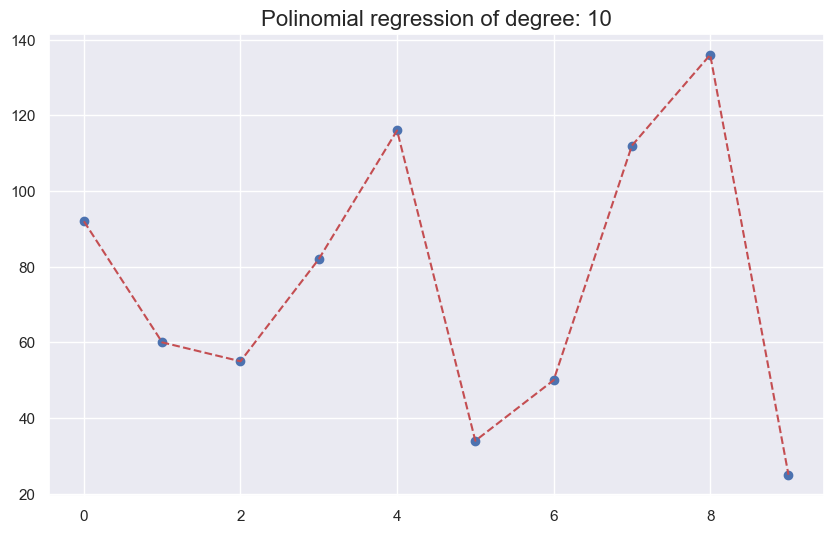

In [9]:
poly_reg_plot(10)

Tornando sul concetto di overfitting, possiamo dire che in generale una delle principali cause di overfitting è legato a quando implementiamo un modello con un alto numero di variabili. Anche se queste non hanno alcuna relazione con la variabile target che vogliamo predire, alcune potrebbero comunque essere trovate (erronemante) statisticamente significative.
In soldoni, abbiamo **overfitting** quando un **modello impara il dettaglio e il rumore dei dati** su cui sta venendo allenato. Questo signica che il *rumore o le fluttuazioni randomiche nei dati di training sono considerati e imparati* come concetti dal modello. Tuttavia, il modello non **sarà in grado di generalizzare bene** sui nuovi dati.

Un metodo comune per controllare l'eventuale presenza di overfitting all'interno di un modello è quello di dividere il dataset in due parti: un training set contenente i dati su cui vogliamo allenare il modello e un testing set in cui invece verificare la bontà del modello stesso. In un certo senso, è come se usassimo una parte di dati vecchi per costruire il modello, nascondendo inizialmente al modello stessi gli altri dati e infine li usassimo come se fossero "nuovi" dati per valutarne la bontà.

<h2 style="font-family: 'Verdana'; color: lightblue;">Training e Test set</h2>

Come detto, è buona norma nell'atto di creazione del modello suddividere il dataset in due parti al fine di valutarne anche la bontà del modello stesso: 
- **training** data set
- **test** data set

La prima regola da tenere a mente è la suddivisione della dimensione campionaria nei due set. La maggior parte dei dati deve andare nella fase di allenamento, perchè ovviamente il modello avrà stime più precise all'aumentare del campione stesso, quindi una suddivisione sensata prevede che circa il 70% dei dati totali siano usato per allenare il modello, mentre il restante 30% per testarne la bontà. Ovviamente la suddivisione, in linea di principio, deve essere casuale. Nella pratica in alcuni casi sono previste delle regole (ad esempio, nel caso di variabili categoriche molto sproporzionate, l'obiettivo sarà creare un test set e un training set in cui la sproporzione sia rispettata in entrambi i set)

La libreria `sklearn` ha un modulo `model_selection` che contiene al suo interno la funzione `train_test_split()`, la quale ci permette proprio di *splittare arrays o matrici in due subset randomici di test e training*.

> E il **validation set**? Alcuni modelli di ML possiedono numerosi parametri (o iperparametri) che necessitano di essere calibrati al fine di migliorare le performance e l'accuratezza del modello, quindi è necessario aggiungere al test e training set anche un validation set a tale scopo:

- training set: dati usati per allenare il modello
- test set: dati usati per valutare la bontà di adattamento del modello
- validation set: dati usati per calibrare gli iperparametri del modello

<h2 style="font-family: 'Verdana'; color: lightblue;">Caso di studio: WHO Life Expectancy</h2>

Proviamo quindi a mettere in pratica quanto detto e ad allenare un modello di regressione lineare multipla, suddividendo il dataset in test e traning set.

In [10]:
df = pd.read_csv('data/who-life-expectancy.csv')
df.head(3)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9


Facciamo un minimo di analisi esplorativa dei dati e di data cleaning

In [11]:
print('Number of countries:', len(df.Country.unique()))

Number of countries: 193


In [12]:
df.Year.unique()

array([2015, 2014, 2013, 2012, 2011, 2010, 2009, 2008, 2007, 2006, 2005,
       2004, 2003, 2002, 2001, 2000])

In [13]:
df.shape

(2938, 22)

Il dataset contiene **2,938 osservazioni** relative a **193 paesi** in un orizzonte temporale di **16 anni** (dal 2000 al 2015). Ci poi sono alcuni valori `nan`, che dobbiamo quindi decidere come gestire.
Alla fine decidiamo di:

- rimuovere i record con valore `nan` per la variabile dipendente; 
- sostituire i valori `nan` ìdei predittori con degli zero;
- rinominare le colonne in modo da assicurarci che non ci siano spazi indesiderati all'inizio e alla fine
- dato che è un dataset temporale, decidiamo di filtrare l'orizzonte temporale e di mantenere solo i dati relativi all'ultimo anno, il 2015. 

In [14]:
df_filt = df[~pd.isna(df["Life expectancy "])]
df_filt.shape

(2928, 22)

Abbiamo quindi rimosso 10 dati che non avevano valori sulla variabile dipendente

In [15]:
df_filt = df_filt.fillna(0)

E sostituito i `nan` con degli zero:

Rinominiamo ora le colonne contenenti gli spazi all'inizio e alla fine

In [16]:
df_filt.columns = df_filt.columns.str.strip()

In [17]:
df15 = df_filt[df_filt.Year==2015]
df15.shape

(183, 22)

Finita la parte di pulizia dei dati, partiamo con la parte di ML vera e propria:
> **Obiettivo**: vogliamo predire la `Life expectancy` dei paesi usando le altre variabili presenti nel dataset come predittori.

Un buon punto di partenza è sempre quello di controllare la **correlazione** tra le variabili dipendenti $y$ e tutti i potenziali predittori (numerici) $X$; a tale fine due ottimi mezzi sono: 
- la matrice di correlazione
- l'analisi grafica dello scatterplot

> Nota: la correlazione può essere calcolata solo tra variabili numeriche; in caso di presenza di variabili non numeriche, come stringhe, è necessario specificare il parametro `numeric_only=True` o, in alternativa, applicare delle tecniche di encoding (codifica) delle variabile categoriche (solitamente vengono codificate in delle variabili dummy).

In [18]:
df15.corr(numeric_only=True)

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
Year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Life expectancy,NaN,1.000000,-0.779119,-0.241290,0.174561,0.043964,0.129036,-0.074617,0.529359,-0.271921,0.515602,-0.015303,0.500300,-0.608345,0.417505,-0.061011,-0.450324,-0.450567,0.627709,0.573656
Adult Mortality,NaN,-0.779119,1.000000,0.188205,-0.133656,-0.042930,-0.063840,0.051196,-0.386325,0.212004,-0.372392,0.032093,-0.322688,0.621012,-0.318438,0.055768,0.277162,0.281968,-0.475533,-0.405246
infant deaths,NaN,-0.241290,0.188205,1.000000,-0.040994,-0.014262,-0.030482,0.800859,-0.223245,0.994196,-0.129729,0.014847,-0.117989,0.095837,-0.112340,0.269383,0.524128,0.524233,-0.186476,-0.187706
Alcohol,NaN,0.174561,-0.133656,-0.040994,1.000000,0.277267,-0.170605,-0.028168,0.145964,-0.042263,0.074014,0.160362,0.071404,-0.062800,0.000039,-0.049404,-0.134058,-0.136482,-0.043374,-0.025639
percentage expenditure,NaN,0.043964,-0.042930,-0.014262,0.277267,1.000000,0.044675,-0.014629,0.038803,-0.014619,0.002150,0.733547,0.034701,-0.036393,-0.020891,-0.010358,-0.014271,-0.012753,0.024865,0.027970
Hepatitis B,NaN,0.129036,-0.063840,-0.030482,-0.170605,0.044675,1.000000,0.038543,0.085943,-0.043456,0.396688,0.003662,0.654456,-0.245951,0.049855,-0.028300,0.077892,0.049352,0.051773,0.049704
Measles,NaN,-0.074617,0.051196,0.800859,-0.028168,-0.014629,0.038543,1.000000,-0.127325,0.764908,-0.028342,-0.011131,-0.001623,-0.026580,-0.068480,0.129888,0.339788,0.334902,-0.046428,-0.042135
BMI,NaN,0.529359,-0.386325,-0.223245,0.145964,0.038803,0.085943,-0.127325,1.000000,-0.235787,0.220717,-0.033182,0.212774,-0.302214,0.304331,-0.021652,-0.434325,-0.451354,0.409818,0.403321
under-five deaths,NaN,-0.271921,0.212004,0.994196,-0.042263,-0.014619,-0.043456,0.764908,-0.235787,1.000000,-0.147457,0.015678,-0.137863,0.122604,-0.116615,0.306521,0.514884,0.513864,-0.204595,-0.204112


In [19]:
df15.corr(numeric_only=True)['Life expectancy'].sort_values(ascending=False)

Life expectancy                    1.000000
Income composition of resources    0.627709
Schooling                          0.573656
BMI                                0.529359
Polio                              0.515602
Diphtheria                         0.500300
GDP                                0.417505
Alcohol                            0.174561
Hepatitis B                        0.129036
percentage expenditure             0.043964
Total expenditure                 -0.015303
Population                        -0.061011
Measles                           -0.074617
infant deaths                     -0.241290
under-five deaths                 -0.271921
thinness  1-19 years              -0.450324
thinness 5-9 years                -0.450567
HIV/AIDS                          -0.608345
Adult Mortality                   -0.779119
Year                                    NaN
Name: Life expectancy, dtype: float64

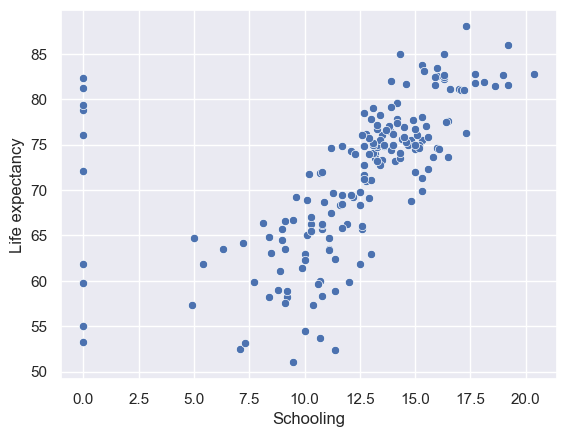

In [20]:
sns.scatterplot(x = 'Schooling', y = 'Life expectancy', data = df15)
plt.show()

<h4 style="font-family: 'Verdana'; color: lightgreen;">Un esempio di encoding: il One Hot Encoding</h4>

Quando abbiamo una variabile categorica con k diverse categorie (ad esempio una variabile "Ruolo" con quattro possibili categorie: Portiere, Difensore, Centrocampista e Attaccante), per far sì che sia lavorabile negli algoritmi di ML è necessario fare i seguenti passaggi:
1. si crea tante nuove colonne quanti sono le possibili categorie
2. Le colonne sono variabili dummy 0/1, che prendono valore 1 quando c'è corrispondenza tra il valore della variabile categorica originale e la nuova colonna, altrimenti 0.
3. si rimuove la colonna originale

In [ ]:
# Dataset di esempio
esempio = pd.DataFrame({
    'Ruolo': [
        'Portiere',
        'Difensore',
        'Centrocampista',
        'Attaccante',
        'Difensore',
        'Attaccante',
        'Centrocampista'
    ]
})

print("Dati originali:")
display(esempio)

# Applichiamo il One Hot Encoding con pandas
esempio_encoded = pd.get_dummies(esempio, columns=['Ruolo']) #pd.get_dummies() crea una nuova colonna per ogni categoria

print("Dati dopo One Hot Encoding:")
display(esempio_encoded)

Dati originali:


,Ruolo
0,Portiere
1,Difensore
2,Centrocampista
3,Attaccante
4,Difensore
5,Attaccante
6,Centrocampista


Dati dopo One Hot Encoding:


,Ruolo_Attaccante,Ruolo_Centrocampista,Ruolo_Difensore,Ruolo_Portiere
0,False,False,False,True
1,False,False,True,False
2,False,True,False,False
3,True,False,False,False
4,False,False,True,False
5,True,False,False,False
6,False,True,False,False


Torniamo all'argomento principale.

Ora applichiamo la funzione `train_test_split` di sklearn: per farlo dobbiamo specificare la matrice $X$ contenente i predittori, il vettore $y$ contenente la variabile target e la proporzione tra i due set:

In [22]:
y = df15['Life expectancy']
X = df15[['Schooling', 'BMI', 'Adult Mortality', 'HIV/AIDS']]
X = sm.add_constant(X)

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Ora definiamo il modello di OLS per effettuare la Regressione lineare multipla ed effettuare il "fit" con i dati di training:

In [24]:
model = sm.OLS(y_train, X_train)
results = model.fit()

In [25]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        Life expectancy   R-squared:                       0.739
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     87.22
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           5.69e-35
Time:                        10:45:31   Log-Likelihood:                -363.64
No. Observations:                 128   AIC:                             737.3
Df Residuals:                     123   BIC:                             751.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              69.0460      1.815     38.048      0.000      65.454      72.638
Schooling           0.3586      0.107      3.357      0.001       0.147       0.570
BMI                 0.1084      0.022      4.860      0.000       0.064       0.153
Adult Mortality    -0.0399      0.005     -7.800      0.000      -0.050      -0.030
HIV/AIDS           -1.1186      0.347     -3.220      0.002      -1.806      -0.431
==============================================================================
Omnibus:                        5.720   Durbin-Watson:                   2.069
Prob(Omnibus):                  0.057   Jarque-Bera (JB):                8.141
Skew:                          -0.144   Prob(JB):                       0.0171
Kurtosis:                       4.202   Cond. No.                         889.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<h2 style="font-family: 'Verdana'; color: lightblue;">Metriche di performance</h2>

Nel valutare un modello (o confrontarlo con un altro), è sempre utile scegliere una **metrica delle performance (o accuratezza) del modello**. Ci sono varie metriche, dipendenti dal tipo di modello su cui stiamo lavorando. Una semplice e popolare metrica per i modelli di regressione è l'**Mean Absolute Error (MAE)**, calcolato come la media delle differenze assolute trai valori osservati della variabile di risposta $y$ e i valori predetti $\hat{y}$:

$$
    MAE = \frac{1}{n} \sum_{i=1}^{n} |y - \hat{y}|
$$

In [26]:
def mae(y, pred): 
    return round(np.mean(np.abs(y - pred)), 2)

Una buona pratica è avere un modello di benchmark con il quale comparare il nostro modello. Per esempio, il **valore medio della variabile target** $\overline{y}$ è un buon benchmark, poichè un modello che performa peggio è un modello sicuramente non buono

Stampiamo il MAE del modello di benchmark (la media della variabile target) e quello del **modello di training**:

In [27]:
pred_train = results.predict(X_train)

print('Naive Training MAE:', mae(y_train, np.mean(y_train))) #naive mae
print('Training MAE:', mae(y_train, pred_train)) # mae

Naive Training MAE: 6.71
Training MAE: 3.06


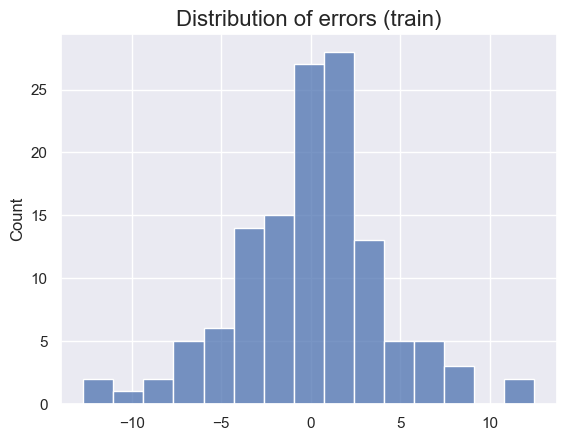

In [28]:
sns.histplot(y_train - pred_train).set_title("Distribution of errors (train)", size=16)
plt.show()

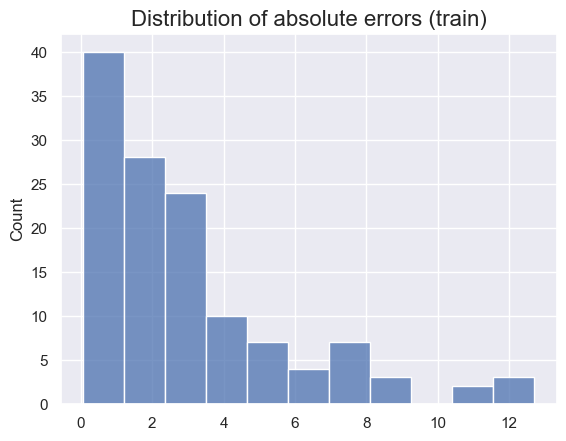

In [29]:
sns.histplot(np.abs(y_train - pred_train)).set_title("Distribution of absolute errors (train)", size=16)
plt.show()

Quindi, fino ad ora, abbiamo soltanto allenato il modello di regressione con il dataset di training, il prossimo passaggio è quello di testare l'accuratezza del modello tramite il test set. Per fare ciò, usiamo i predittori dal test set `X_test` per fare predizioni con il modello appena allenato, che confronteremo con i valori di risposta osservati in `y_test`. 

Infine, possiamo stampare il MAE con $\overline{y}$ e quello del modello di testing:

In [30]:
pred_test = results.predict(X_test)

print('Naïve Testing MAE:', mae(y_test, np.mean(y_test))) #naive mae
print('Testing MAE:', mae(y_test, pred_test)) # mae

Naïve Testing MAE: 6.71
Testing MAE: 3.36


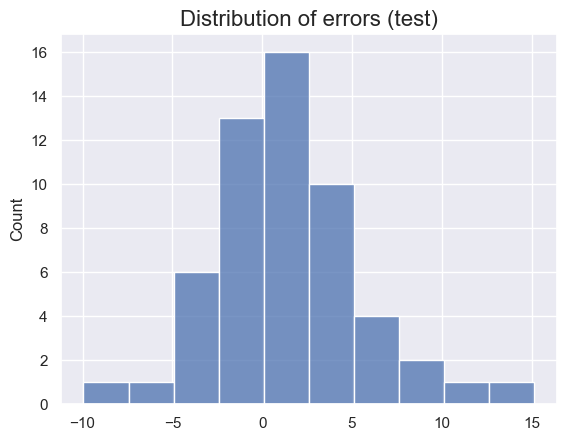

In [31]:
sns.histplot(y_test - pred_test).set_title("Distribution of errors (test)", size=16)
plt.show()

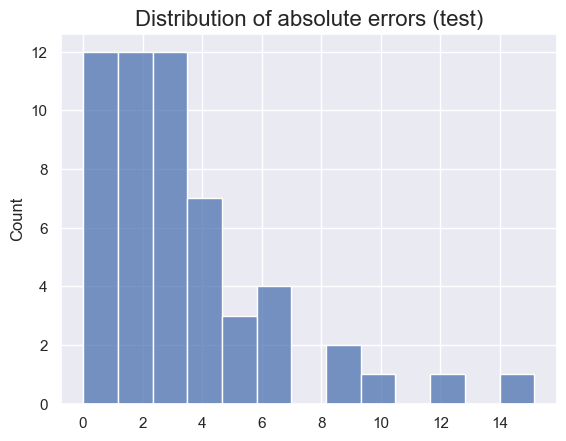

In [32]:
sns.histplot(np.abs(y_test - pred_test)).set_title("Distribution of absolute errors (test)", size=16)
plt.show()

**Confrontiamo quindi il risultato dei MAE del training con quello del testing**: possiamo concludere che il modello non overfitta i dati, in quanto il MAE dei due set è molto simile.